## Imports / Functions / Loading Data

In [1]:
import pandas as pd
import numpy as np
import inflection

import pickle 

import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.under_sampling import RandomUnderSampler

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import  RFECV, RFE

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB, GaussianNB, CategoricalNB
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from lightgbm import LGBMClassifier as LGBM

from sklearn.pipeline import Pipeline

from IPython.core.display import HTML
# import scipy
import sklearn.metrics as mt
import scikitplot as skplt

from category_encoders import TargetEncoder, OneHotEncoder

import warnings
warnings.filterwarnings( 'ignore' )

In [2]:
# Modificações do EDA-Notebook
def columns_rename(dataset):

    # Modificação nomes colunas
    snakecase = lambda x : inflection.underscore( x )

    new_columns = list( map( snakecase, dataset.columns ) )

    dataset.columns = new_columns

    return dataset


def jupyter_settings():
    %matplotlib inline
    
    plt.style.use( 'bmh' )
    plt.rcParams['figure.figsize'] = [14, 9]
    plt.rcParams['font.size'] = 26
    
    display( HTML( '<style>.container { width:80% !important; }</style>') )
    pd.options.display.max_columns = None
    pd.options.display.max_rows = None
    pd.set_option( 'display.expand_frame_repr', False )
    
    sns.set()
    
jupyter_settings()

In [3]:
df_raw   = pd.read_csv('data/train.csv').drop(columns='id')
df = columns_rename(df_raw)

In [4]:
df.head()

,gender,age,driving_license,region_code,previously_insured,vehicle_age,vehicle_damage,annual_premium,policy_sales_channel,vintage,response
0,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


## 0- Planejamento de Modelagem

##### Preparação

- Não será realizada Feature Engineering no primeiro turno

- Classificação desbalanceada

- No primeiro turno rodaremos o modelo com todas as variáveis usando algorítmo de árvore para encontrar as 'features importances' de cada uma.

- Variáveis driving_license, vintage apresentaram sinais de pouca importância na EDA para o modelo, mas serão mantidas no primeiro turno

- Criação de faixas etárias (bins) pode ajudar o Classificador (Na EDA obteve ganho de correlação com o Target)

- A média de propensão das variáveis region_code e age demonstrou alguma relevância durante a EDA.

- Tratar outliers na var. annual_premium (Em algorítmo de Árvore, desnecessária Padronização (Standard Scaler) )

##### Round 1

- RESUMO: O desbalanciamento do data set atrapalhou o algoritmo performar. Porém o algorítmo apresentou performace média (F1 Score) de 42%  usando o balanciamento (class_weight) e a seleção de features mais importantes indicadas da própria Random Forest.

- Com o dataset desbalanciado, algorírmos sem a função de Bootstrap ou Bagging tiveram performace menor que 10%

- Nesta etapa as variáveis driving_license, vintage não contribuíram para o modelo

- A criação de Faixa Etária ajudou pouco no primeiro treino, mas será realizada nova tentativa.

- Predomínio de uso do One Hot Encoder nas variáveis categóricas

##### Round 2

- RESUMO: Nesta etapa foi utilizada RandomUnderSampler(sampling_strategy=0.40) apenas sobre o dataset de treino. 

- Outliers do annual_premium serão tratados nesta etapa

- Usando árvores de decisão não foi necessário Rescaling e Standadization dos dados

- Predomínio da estratégia de criação de variáveis baseada nas suas médias ( Target Enconding )

- Usando técnica de balanciamento do dataset o GradientBooster performou melhor e se tornou candidato ao modelo

- Método de Recursive Feature Elimination (Feature Selection) foi usado para filtar as variáveis importantes para cada algorítimo separadamente

- Melhora do F1 Score para 47% e resultado no Ranking de 50% no top k=100

## 1- Feature Engineering

##### Data pre-processing

In [6]:
# Separação das Features e do Target
# X = df.drop(columns='response').copy()
# y = df['response'].copy()

In [5]:
# Remoção dos outliers identificados na variável Annual_Premium 
# (Valores baixos / promocionais e valores muito acima da distribuíção estatística [1.5x 4Q]) 

df = df.loc[(df['annual_premium'] > 9000) & (df['annual_premium'] < 91000), :]

In [7]:
# Criação das Bins Age e Vintage (Feature Engineering)
X['age_group'] = pd.cut(X['age'], bins=13, labels=False)

X['vintage_group'] = pd.cut(X['vintage'], bins=100, labels=False )

In [8]:
# Balanceamento dos dados com Random Under Sampling
under = RandomUnderSampler(sampling_strategy=0.50)
X, y = under.fit_resample(X, y)

##### Encoding

In [8]:
# # Target Encoder ( As médias dos agrupamentos destas variáveis demonstraram relevância durante a EDA )
target = TargetEncoder(cols=['age', 'age_group', 'region_code', 'policy_sales_channel',
                              'vintage','vintage_group', 'vehicle_age', 'gender'])

# # OneHot Encoder ( Variáveis categóricas, com baixa cardinalidade, que descrevem diferentes estados do fenômeno )
onehot = OneHotEncoder(cols=['vehicle_damage'])

# pca = PCA(n_components=.98)
# scaler = StandardScaler()

# X = onehot.fit_transform(X)
# X = target.fit_transform(X, y)


## 2- Feature Selection

#### Embendded Methods

In [123]:
# Método de Embendded Selection com LightGBM
model1 = LGBM(n_jobs=-1)

pipeline1 = Pipeline(steps=[ 
                             ('enc1' , onehot ),
                             ('enc2' , target ),
                             ('model', model1  ) ] )

pipeline1.fit(X, y)

NameError: name 'X' is not defined

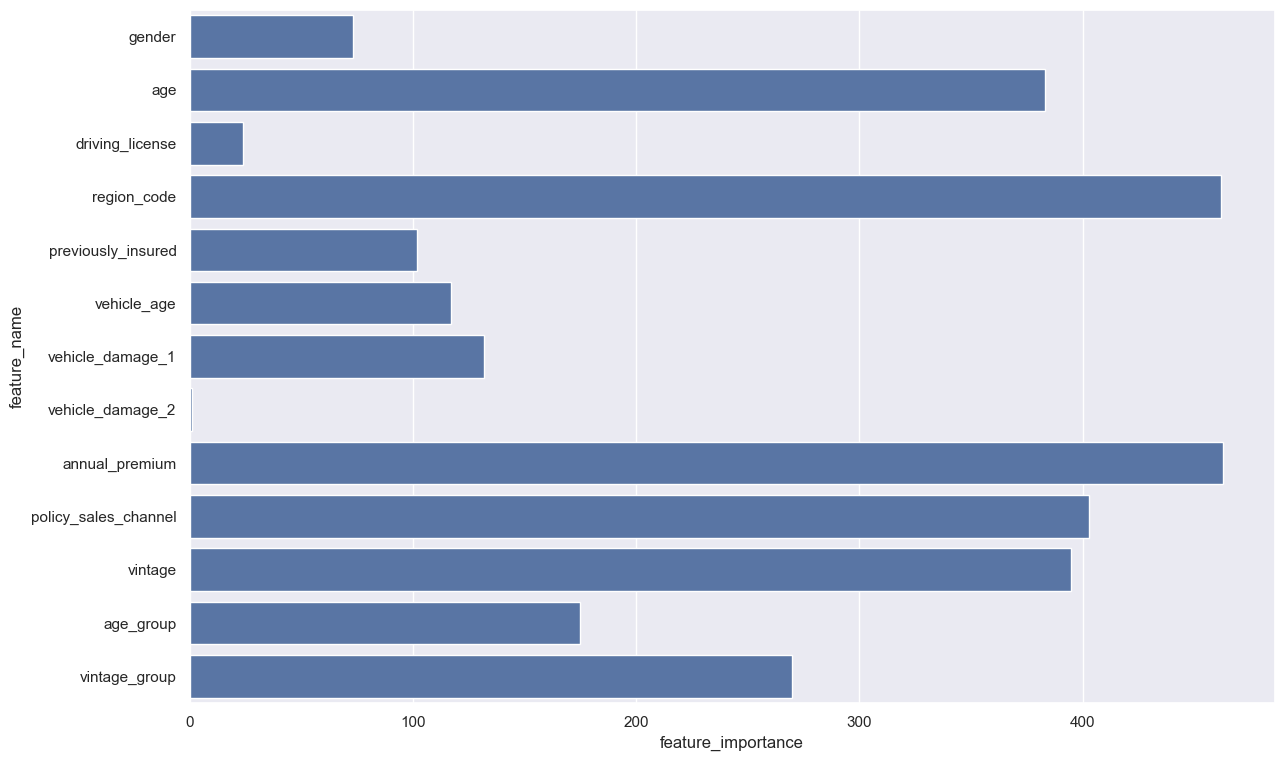

In [11]:
# Features importances table
feature_score1 = pd.DataFrame(
                            { 'feature_name': pipeline1[2].feature_name_ ,
                              'feature_importance': pipeline1[2].feature_importances_ }
                            )
sns.barplot(data=feature_score1, x='feature_importance', y='feature_name');

In [12]:
model2 = RandomForestClassifier(n_estimators=200, n_jobs=-1)

pipeline2 = Pipeline(steps=[ 
                             ('enc1' , onehot ),
                             ('enc2' , target ),
                             ('model', model2  ) ] )

pipeline2.fit(X, y)

Pipeline(steps=[('enc1', OneHotEncoder(cols=['vehicle_damage'])),
                ('enc2',
                 TargetEncoder(cols=['age', 'age_group', 'region_code',
                                     'policy_sales_channel', 'vintage',
                                     'vintage_group', 'vehicle_age',
                                     'gender'])),
                ('model', RandomForestClassifier(n_estimators=200, n_jobs=-1))])

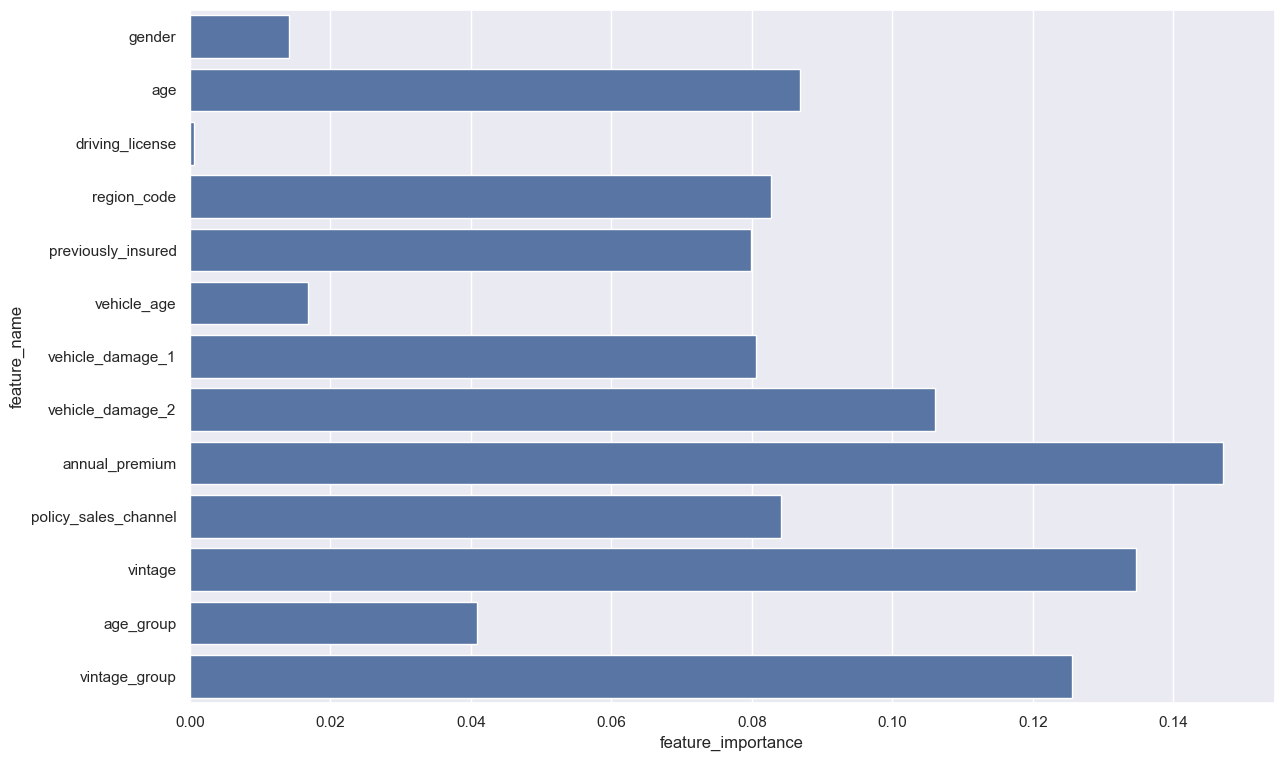

In [13]:
# Features importances table
feature_score2 = pd.DataFrame(
                            { 'feature_name': pipeline2[2].feature_names_in_ ,
                              'feature_importance': pipeline2[2].feature_importances_ }
                            )
sns.barplot(data=feature_score2, x='feature_importance', y='feature_name');

In [14]:
model3 = GradientBoostingClassifier(n_estimators=200)

pipeline3 = Pipeline(steps=[ 
                             ('enc1' , onehot ),
                             ('enc2' , target ),
                             ('model', model3  ) ] )

pipeline3.fit(X, y)


Pipeline(steps=[('enc1', OneHotEncoder(cols=['vehicle_damage'])),
                ('enc2',
                 TargetEncoder(cols=['age', 'age_group', 'region_code',
                                     'policy_sales_channel', 'vintage',
                                     'vintage_group', 'vehicle_age',
                                     'gender'])),
                ('model', GradientBoostingClassifier(n_estimators=200))])

<Axes: xlabel='feature_importance', ylabel='feature_name'>

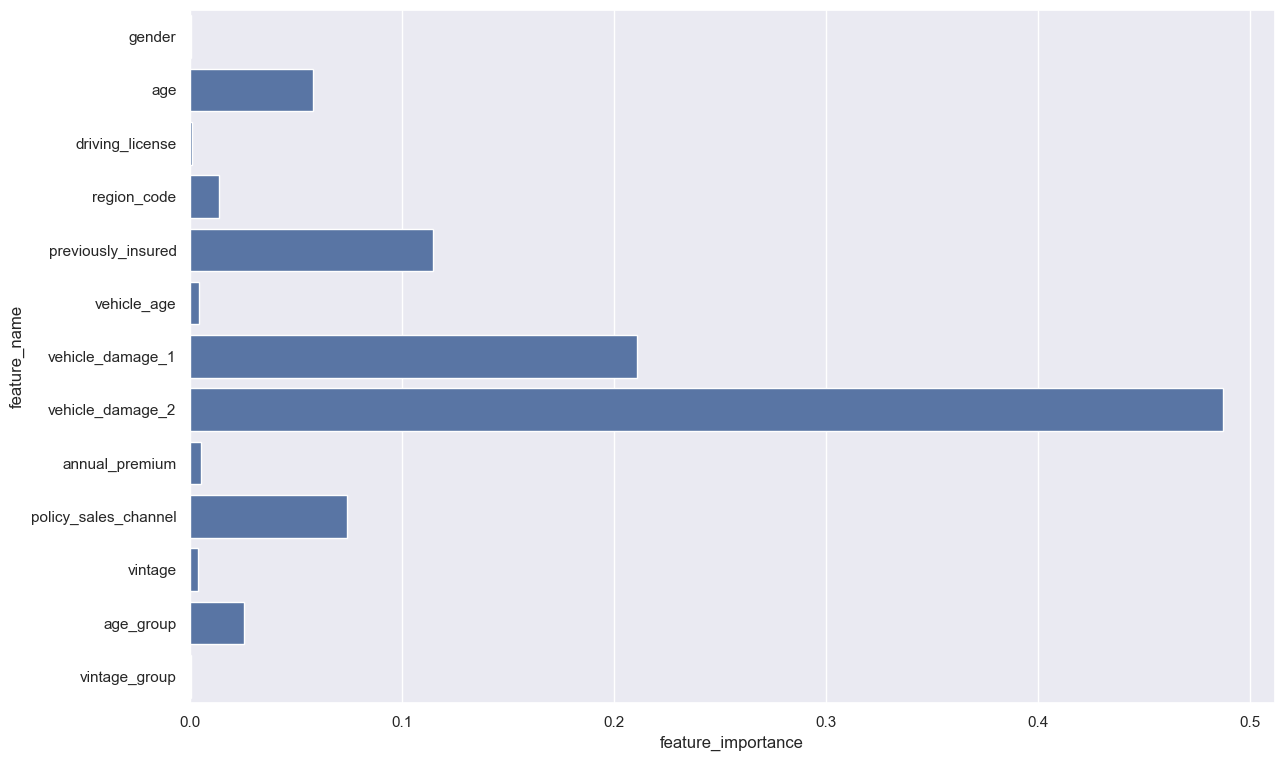

In [15]:
# Features importances table
feature_score3 = pd.DataFrame(
                            { 'feature_name': pipeline3[2].feature_names_in_ ,
                              'feature_importance': pipeline3[2].feature_importances_ }
                            )
sns.barplot(data=feature_score3, x='feature_importance', y='feature_name')

#### Wrapper Methods

##### Recursive Feature Elimination

In [16]:
# Uso de Recursive Feature Elimination para Feature Selection
rfe_LGB = RFECV(estimator=LGBM( n_jobs= -1 ), cv=4, n_jobs=-1, min_features_to_select=5) 
pipe_LGB = Pipeline(steps=[ ('enc1' , onehot ),
                            ('enc2' , target ),
                            ('model', rfe_LGB ) ] )
pipe_LGB.fit(X, y)


[LightGBM] [Info] Number of positive: 35033, number of negative: 70065
[LightGBM] [Info] Number of positive: 35032, number of negative: 70065
[LightGBM] [Info] Number of positive: 35033, number of negative: 70065
[LightGBM] [Info] Number of positive: 35032, number of negative: 70065
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004151 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 858
[LightGBM] [Info] Number of data points in the train set: 105098, number of used features: 13
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006853 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 855
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333337 -> initscore=-0.693133
[LightGBM] [Info] Number of data points in the train set: 105097, number of used feature

Pipeline(steps=[('enc1', OneHotEncoder(cols=['vehicle_damage'])),
                ('enc2',
                 TargetEncoder(cols=['age', 'age_group', 'region_code',
                                     'policy_sales_channel', 'vintage',
                                     'vintage_group', 'vehicle_age',
                                     'gender'])),
                ('model',
                 RFECV(cv=4, estimator=LGBMClassifier(n_jobs=-1),
                       min_features_to_select=5, n_jobs=-1))])

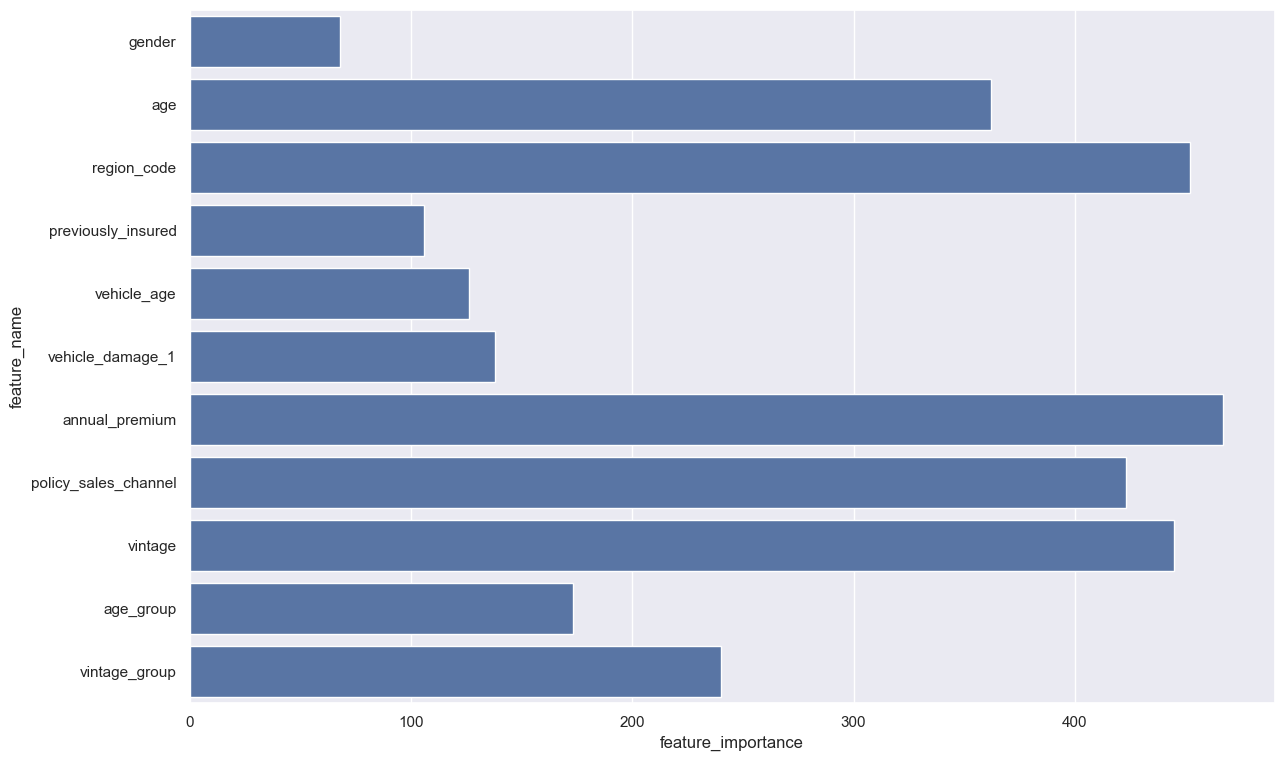

In [17]:
# Lista 1 de Features para seleção
rfe_feat_selection = [ pipe_LGB[2].feature_names_in_[index] 
                        for index, value in enumerate(pipe_LGB[2].support_) 
                        if value == True 
                        ]

# Features importances table
feature_score_pipe = pd.DataFrame(
                            { 'feature_name': rfe_feat_selection ,
                              'feature_importance': pipe_LGB[2].estimator_.feature_importances_ 
                              } )

sns.barplot(data=feature_score_pipe, x='feature_importance', y='feature_name')

In [ ]:
# # Lista 2 de Features para seleção
# rfe_feat_selection2 = [ pipe_LGB[2].feature_names_in_[index] 
#                         for index, value in enumerate(pipe_LGB[2].support_) 
#                         if value == True 
#                         ]

# # Features importances table
# feature_score_pipe2 = pd.DataFrame(
#                             { 'feature_name': rfe_feat_selection2 ,
#                               'feature_importance': pipe_LGB[2].estimator_.feature_importances_ 
#                               } )

# sns.barplot(data=feature_score_pipe2, x='feature_importance', y='feature_name');

#### Resumo do Feature Selection

- Os diferentes estimadores identificaram importância de features distintas. Para cada um deles será criado um subset diferente

- As Features criadas através de Bins não superam as Variáveis originais (Serão levadas para (des)validação ) (Porém ainda ajudam no aprendizado de alguns algorítmos) 

- Nenhum dos algorítmos usados encontraram importância para a feature Driving_License


## 3- Model Training

In [6]:
y1 = df['response']
X1 = df.drop(columns='response')




# Função de preparação dos dados para os algorítimos (Diferentes estimadores usam diferentes features p/ o treinamento)
def model_data_preset(X, y, train_size=.75, col_drop_list: list =None, 
                      under_sampling: float =0.40, create_age_group=False, create_vintage_group=False):
    
    # Train-Validation Data Split
    X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=train_size)

    # Creating new features
    if create_age_group:
        X_train['age_group'] = pd.cut(X_train['age'], bins=13, labels=False)
        X_valid['age_group'] = pd.cut(X_valid['age'], bins=13, labels=False)
    if create_vintage_group:
        X_train['vintage_group'] = pd.cut(X_train['vintage'], bins=100, labels=False )
        X_valid['vintage_group'] = pd.cut(X_valid['vintage'], bins=100, labels=False )

        # Droppar variáveis de baixa importância
    if col_drop_list:
        X_train = X_train.drop(columns=col_drop_list)
        X_valid = X_valid.drop(columns=col_drop_list)
    else:
        None    

    # Under Sampling for imbalanced dataset
    if 1.0 > under_sampling > 0.0:
        under = RandomUnderSampler(sampling_strategy=under_sampling)
        X_train, y_train = under.fit_resample(X_train, y_train)
    else:
        None

    return X_train, X_valid, y_train, y_valid

def scoring(y_valid, pred):
    # General Scoring
    # print('F1-Score', mt.f1_score(y_valid, pred))
    # print('Curva ROC AUC', mt.roc_auc_score(y_valid, pred))
    x = mt.f1_score(y_valid, pred)
    y = mt.roc_auc_score(y_valid, pred)

    return x,y


def get_predictions( model ):

    pipeline = Pipeline(steps=[ 
                                ('enc1' , onehot ),
                                ('enc2' , target ),
                                # ('scal' , scaler ),
                                # ('pca1' , pca    ),
                                ('model', model  ) ] )

    pipeline.fit(X_train, y_train)
    prediction  = pipeline.predict(X_valid)
    pred_proba  = pipeline.predict_proba(X_valid)

    return prediction, pred_proba


In [139]:
# #### Estimator 1 - Random Forest
# # Random Forest - Data Preset

X_train, X_valid, y_train, y_valid = model_data_preset(X1, y1, col_drop_list=['driving_license', 'gender'], train_size=0.80, under_sampling=0.5,
                                               create_age_group=False, create_vintage_group=True )

# Encoders Config - Random Forest
onehot = OneHotEncoder(cols=[ 'vehicle_damage', 'previously_insured'])
target = TargetEncoder(cols=['age', 'region_code', 'policy_sales_channel', 'vehicle_age', 'vintage_group'])


In [126]:
X_train.columns

Index(['age', 'region_code', 'previously_insured', 'vehicle_age',
       'vehicle_damage', 'annual_premium', 'policy_sales_channel', 'vintage',
       'vintage_group'],
      dtype='object')

#### Treinamento Random Forest

In [127]:
# Treinamento Random Forest
model1 = RandomForestClassifier(n_estimators=117, bootstrap=True, n_jobs=-1)

pred1, pred01 = get_predictions(model1)
scoring(y_valid, pred1)

(0.437015898899307, 0.75057219654784)

<Axes: title={'center': 'Cumulative Gains Curve'}, xlabel='Percentage of sample', ylabel='Gain'>

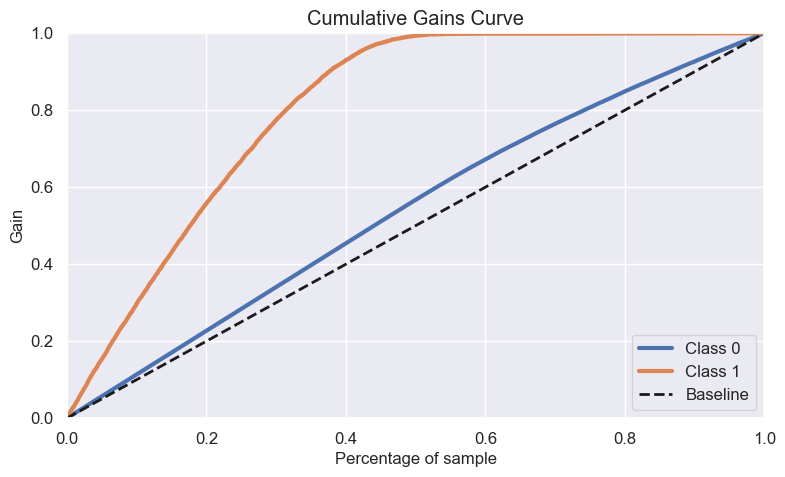

In [128]:
# Cumulative Gain Curve for ranking purpose
skplt.metrics.plot_cumulative_gain(y_valid, pred01, figsize=(9,5))

#### Treinamento LGBM

In [154]:
# Treinamento LGBM - Melhor algorítmo
model2 = LGBM(n_estimators=97, n_jobs=-1)

pred2, pred02 = get_predictions( model2 )
scoring(y_valid, pred2)

[LightGBM] [Info] Number of positive: 30346, number of negative: 60692
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000773 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 814
[LightGBM] [Info] Number of data points in the train set: 91038, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333333 -> initscore=-0.693147
[LightGBM] [Info] Start training from score -0.693147


(0.4673859549498391, 0.7891962118610876)

<Axes: title={'center': 'Cumulative Gains Curve'}, xlabel='Percentage of sample', ylabel='Gain'>

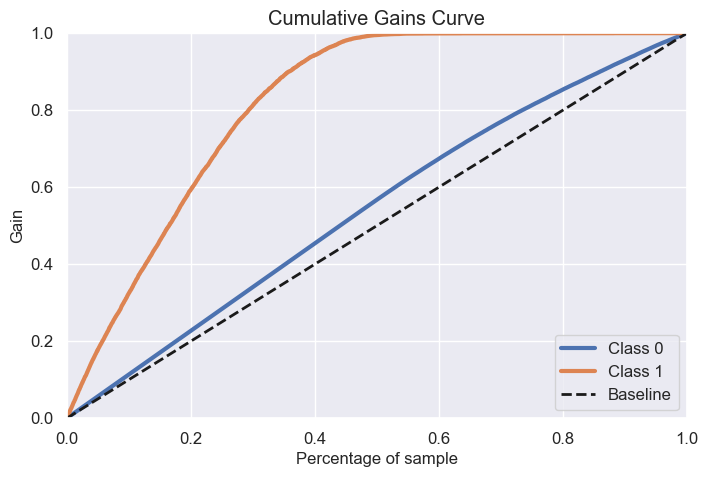

In [130]:
skplt.metrics.plot_cumulative_gain(y_valid, pred02, figsize=(8,5))

In [158]:
df.head()

,gender,age,driving_license,region_code,previously_insured,vehicle_age,vehicle_damage,annual_premium,policy_sales_channel,vintage,response
0,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


[LightGBM] [Info] Number of positive: 30346, number of negative: 60692
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000848 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 814
[LightGBM] [Info] Number of data points in the train set: 91038, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333333 -> initscore=-0.693147
[LightGBM] [Info] Start training from score -0.693147
[LightGBM] [Info] Number of positive: 30346, number of negative: 60692
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000811 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 814
[LightGBM] [Info] Number of data points in the train set: 91038, number of used features: 11
[LightGBM] [Info] [b

<Axes: >

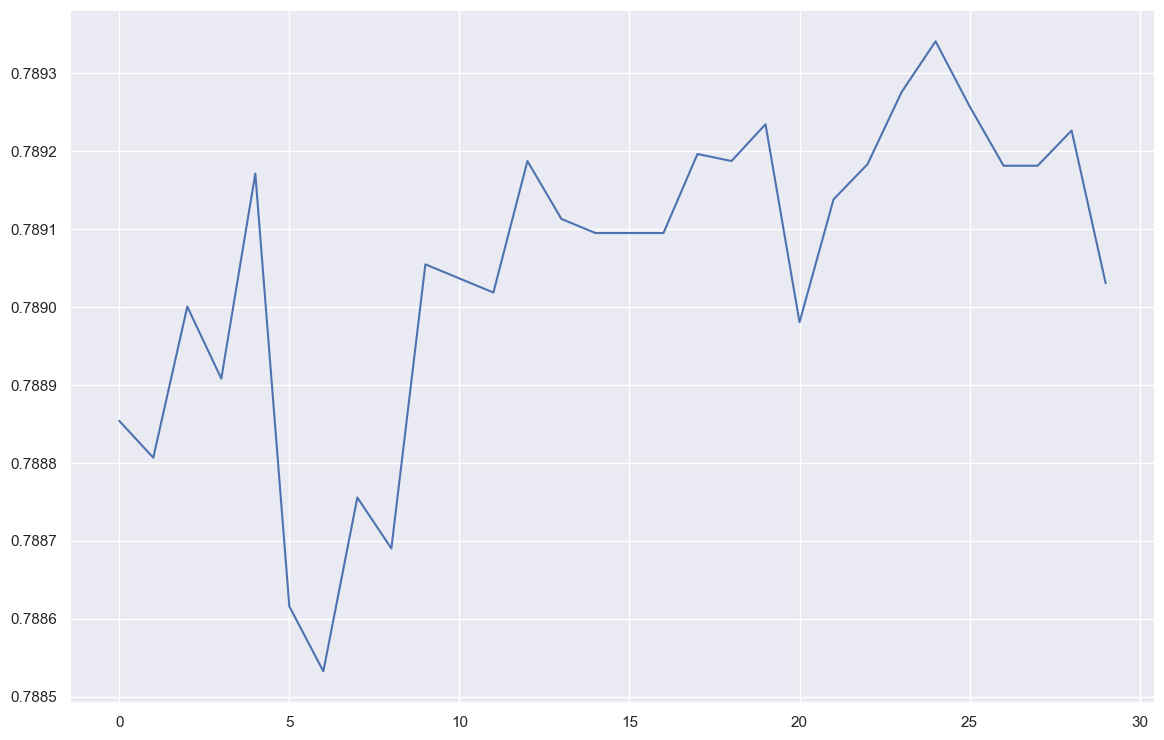

In [140]:
result = []
for n in range(80, 110, 1):
    # Treinamento LGBM - Melhor algorítmo   
    model2 = LGBM(n_estimators=n, n_jobs=-1)

    pred2, pred02 = get_predictions( model2 )
    _,y = scoring(y_valid, pred2)
    result.append(y)

sns.lineplot(result)


#### Treinamento Gradient Boosting

In [152]:

model3 = GradientBoostingClassifier(n_estimators=82)

pred3, pred03 = get_predictions( model3 )
scoring(y_valid, pred3)

(0.4623179227359088, 0.7877062479047816)

<Axes: title={'center': 'Cumulative Gains Curve'}, xlabel='Percentage of sample', ylabel='Gain'>

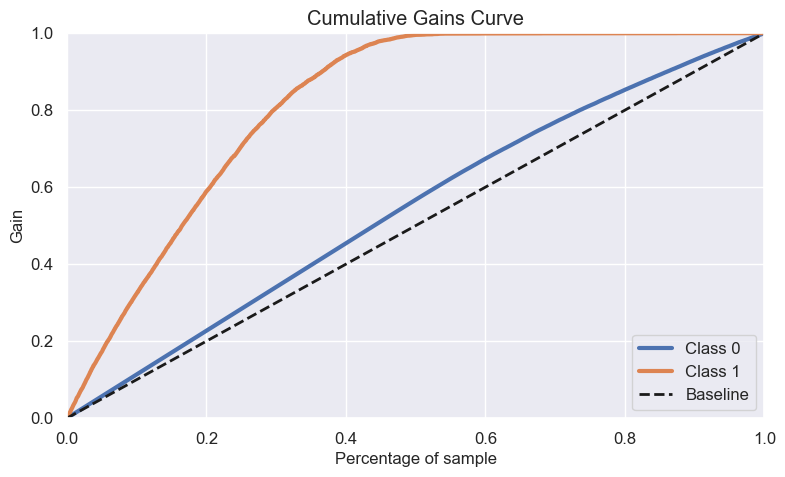

In [132]:
skplt.metrics.plot_cumulative_gain(y_valid, pred03, figsize=(9,5))

#### Treinamento Logistic Regression

In [149]:
model4 = LogisticRegression(C=1.6, n_jobs=-1, penalty='l1', solver='liblinear')

pred4, pred04 = get_predictions( model4 )
scoring(y_valid, pred4)

(0.4561826484018265, 0.7857966003795539)

<Axes: title={'center': 'Cumulative Gains Curve'}, xlabel='Percentage of sample', ylabel='Gain'>

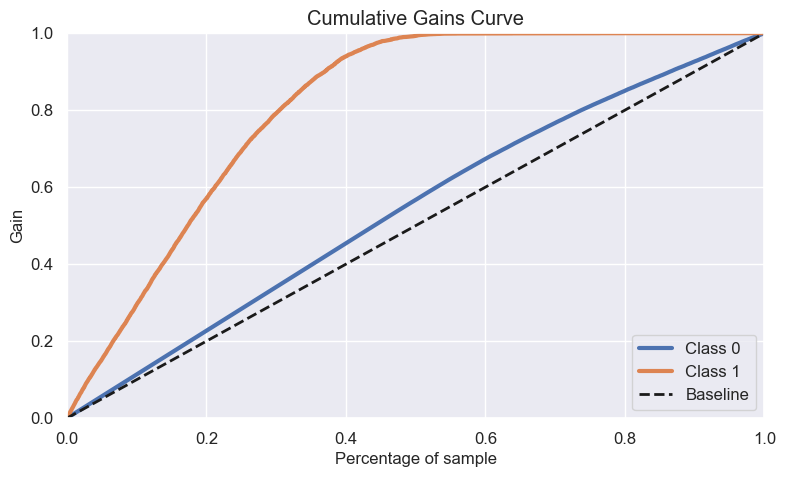

In [134]:
skplt.metrics.plot_cumulative_gain(y_valid, pred04, figsize=(9,5))

#### Resumo dos Scores

## 4- Model Performance

##### Funções do cálculo de performance

In [17]:
# O custo de perder potenciais cliente (falso negativo) é alto - 
# Já o custo de direcionar oferta a cliente não interessado (falso positivo) é razoável
# Assim adotamos o Recall como métrica para mitigar os falso negativos

def recall_at_k( data, k=1000):
    # reset index
    data = data.reset_index( drop=True )

    # create ranking oreder
    data['ranking'] = data.index + 1

    data['recall_at_k'] = data['response'].cumsum() / data['response'].sum()

    return data.loc[k, 'recall_at_k']

##### Performance Random Forest

In [135]:
# Agregar os dados
df4 = pd.concat([X_valid, y_valid], axis=1)

# Gerar o score de propensão de compra
df4['score'] = pred04[:,1].tolist()
df4 = df4.sort_values('score', ascending=False)

recall    = recall_at_k   (df4, k=20000)

# print(f'Precision at K: {round(precision * 100, 2)}%')
print(f'Recall    at K: {round(recall * 100, 2)}%')

Recall    at K: 82.12%


##### Performance LGBM

In [155]:
# Agregar os dados
df4 = pd.concat([X_valid, y_valid], axis=1)

# Gerar o score de propensão de compra
df4['score'] = pred02[:,1].tolist()
df4 = df4.sort_values('score', ascending=False)

recall    = recall_at_k   (df4, k=20000)

# print(f'Precision at K: {round(precision * 100, 2)}%')
print(f'Recall    at K: {round(recall * 100, 2)}%')

Recall    at K: 83.62%


##### Performance Gradient Boosting

In [153]:
# Agregar os dados
df4 = pd.concat([X_valid, y_valid], axis=1)

# Gerar o score de propensão de compra
df4['score'] = pred03[:,1].tolist()
df4 = df4.sort_values('score', ascending=False)

recall    = recall_at_k   (df4, k=20000)

# print(f'Precision at K: {round(precision * 100, 2)}%')
print(f'Recall    at K: {round(recall * 100, 2)}%')

Recall    at K: 83.12%


#### Performance Logistic Regression

In [150]:
# Agregar os dados
df4 = pd.concat([X_valid, y_valid], axis=1)

# Gerar o score de propensão de compra
df4['score'] = pred04[:,1].tolist()
df4 = df4.sort_values('score', ascending=False)

recall    = recall_at_k   (df4, k=20000)

# print(f'Precision at K: {round(precision * 100, 2)}%')
print(f'Recall    at K: {round(recall * 100, 2)}%')

Recall    at K: 82.1%


In [157]:
# Salvando o modelo e os encoders

model2 = LGBM(n_estimators=97, n_jobs=-1)

pipeline = Pipeline(steps=[ 
                            ('enc1' , onehot ),
                            ('enc2' , target ),
                            ('model', model2  ) ] )

pipeline.fit(X_train, y_train)

with open('api/lgbm(83.6).pkl', 'wb') as file:
    pickle.dump(pipeline, file)


[LightGBM] [Info] Number of positive: 30346, number of negative: 60692
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000770 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 814
[LightGBM] [Info] Number of data points in the train set: 91038, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333333 -> initscore=-0.693147
[LightGBM] [Info] Start training from score -0.693147


In [160]:
df4.head()

,age,region_code,previously_insured,vehicle_age,vehicle_damage,annual_premium,policy_sales_channel,vintage,vintage_group,response,score
32172,34,18.0,0,< 1 Year,Yes,32445.0,26.0,208,68,0,0.865637
147373,30,18.0,0,1-2 Year,Yes,21941.0,155.0,217,71,1,0.865036
89023,38,18.0,0,1-2 Year,Yes,24434.0,156.0,299,99,0,0.852442
103931,31,11.0,0,< 1 Year,Yes,22058.0,124.0,298,99,1,0.842680
66038,34,11.0,0,< 1 Year,Yes,19939.0,124.0,163,52,1,0.836804


In [163]:
def categoria(x):
    var = ''
    if x> 0.80:
        var = 'Muito Alta' 
    elif 0.80 >= x >0.60:
        var = 'Alta'
    elif 0.60 >= x >0.40:
        var = 'Médio' 
    else:
        var = 'Baixo'
    return var

In [164]:
df4['classif'] = df4['score'].apply(categoria)
df4.head(15)

,age,region_code,previously_insured,vehicle_age,vehicle_damage,annual_premium,policy_sales_channel,vintage,vintage_group,response,score,classif
32172,34,18.0,0,< 1 Year,Yes,32445.0,26.0,208,68,0,0.865637,Muito Alta
147373,30,18.0,0,1-2 Year,Yes,21941.0,155.0,217,71,1,0.865036,Muito Alta
89023,38,18.0,0,1-2 Year,Yes,24434.0,156.0,299,99,0,0.852442,Muito Alta
103931,31,11.0,0,< 1 Year,Yes,22058.0,124.0,298,99,1,0.842680,Muito Alta
66038,34,11.0,0,< 1 Year,Yes,19939.0,124.0,163,52,1,0.836804,Muito Alta
81903,30,35.0,0,< 1 Year,Yes,27841.0,124.0,209,68,1,0.836038,Muito Alta
34394,30,3.0,0,< 1 Year,Yes,24370.0,157.0,210,69,1,0.835141,Muito Alta
313720,30,28.0,0,1-2 Year,Yes,24330.0,157.0,291,97,1,0.833343,Muito Alta
103556,33,18.0,0,< 1 Year,Yes,22213.0,124.0,247,82,0,0.822682,Muito Alta
309890,33,3.0,0,< 1 Year,Yes,25282.0,124.0,98,30,1,0.822570,Muito Alta
